# IMPORT LIBRARIES


In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

import joblib

# LOAD DATASET & BASIC INFORMATION


In [17]:
file_path = 'tesla_deliveries_dataset_2015_2025.csv'

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)       

In [18]:
print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values
Year                    0
Month                   0
Region                  0
Mo

# DATA CLEANING & PREPROCESSING


In [19]:
# Remove duplicates

df.drop_duplicates(inplace=True)

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=np.number).columns

num_imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Fill missing categorical values
categorical_cols = df.select_dtypes(include='object').columns

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("\nMissing values after cleaning")
print(df.isnull().sum())


Missing values after cleaning
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [20]:
# Automatically detect date column
possible_date_cols = [
    col for col in df.columns
    if 'date' in col.lower() or 'year' in col.lower()
]

print("\nPossible Date Columns:", possible_date_cols)

# Example assumption
# Replace with your actual column name if needed
# Create synthetic date column using Year and Month
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

DATE_COLUMN = 'Date'

# Convert to datetime

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])

# Extract features

df['year'] = df[DATE_COLUMN].dt.year
df['month'] = df[DATE_COLUMN].dt.month
df['quarter'] = df[DATE_COLUMN].dt.quarter



Possible Date Columns: ['Year']


# EXPLORATORY DATA ANALYSIS (EDA)


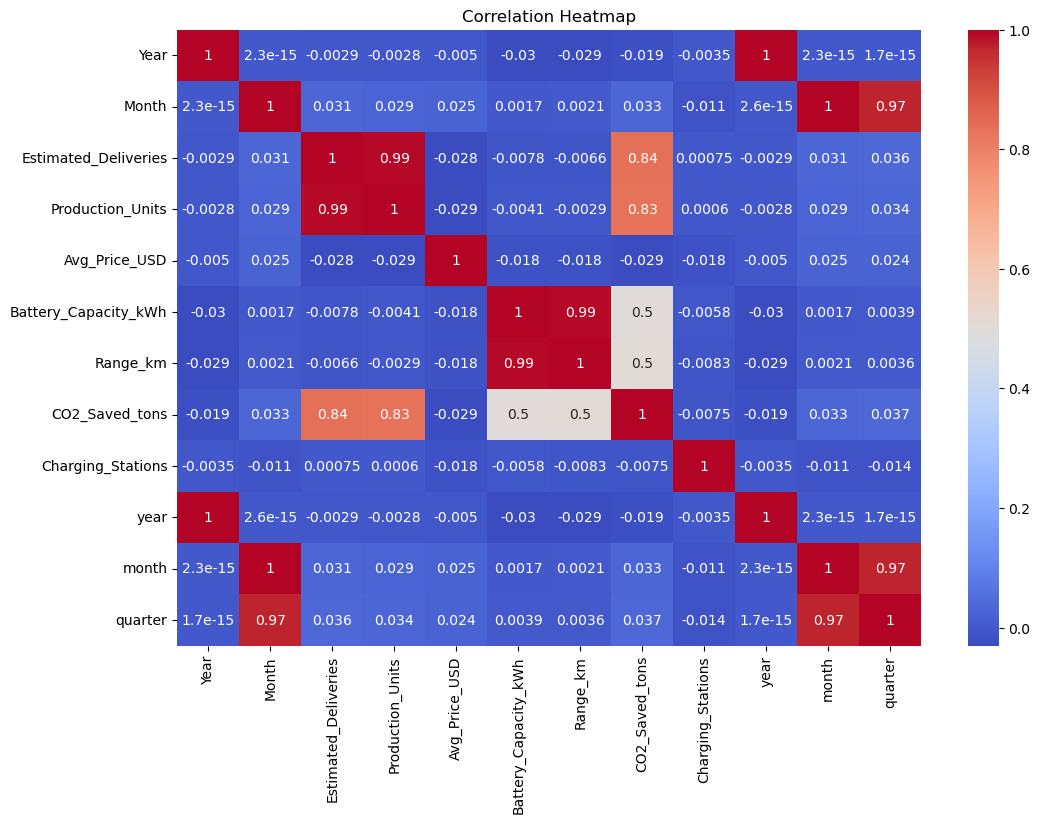

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

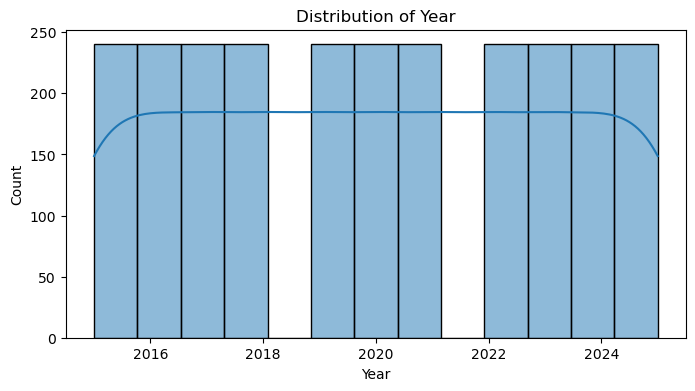

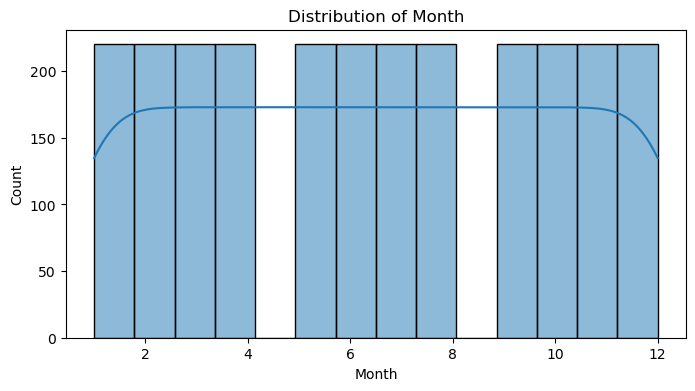

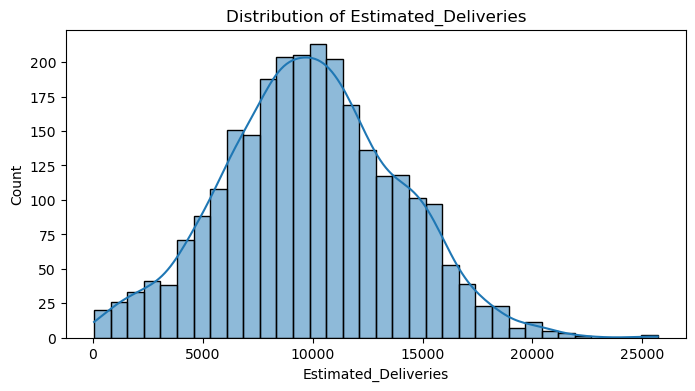

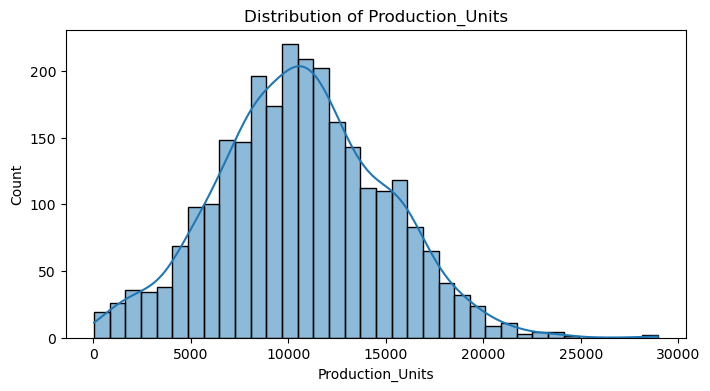

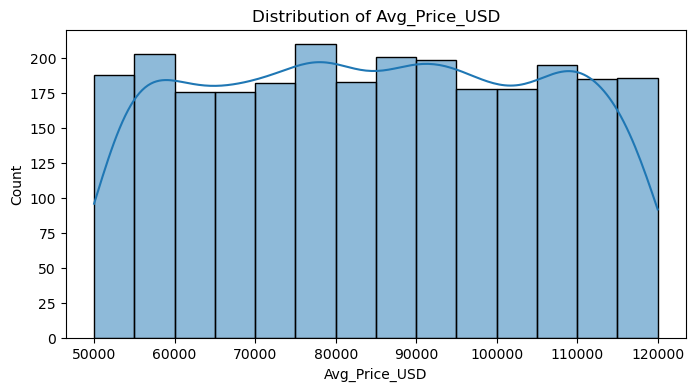

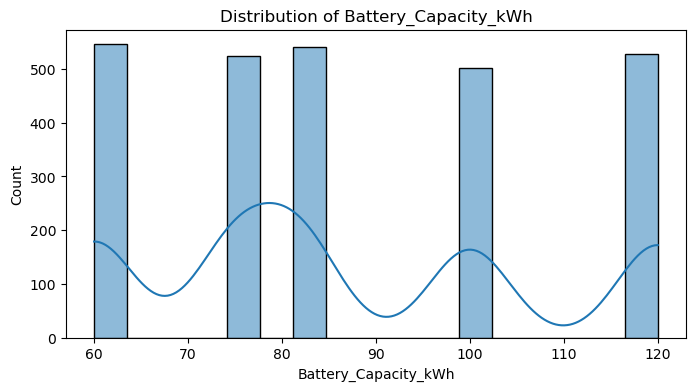

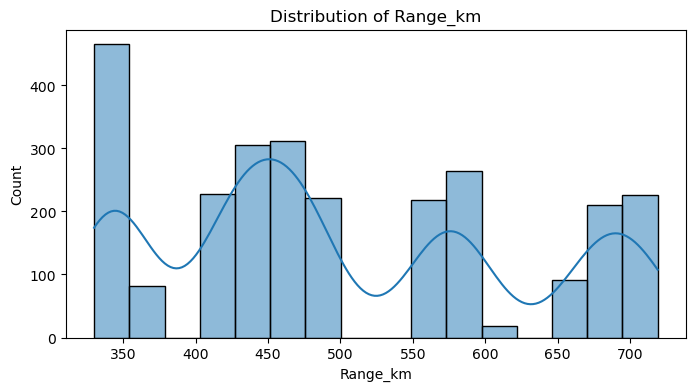

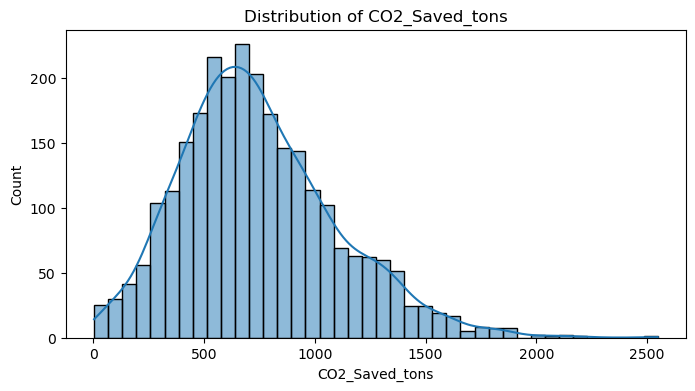

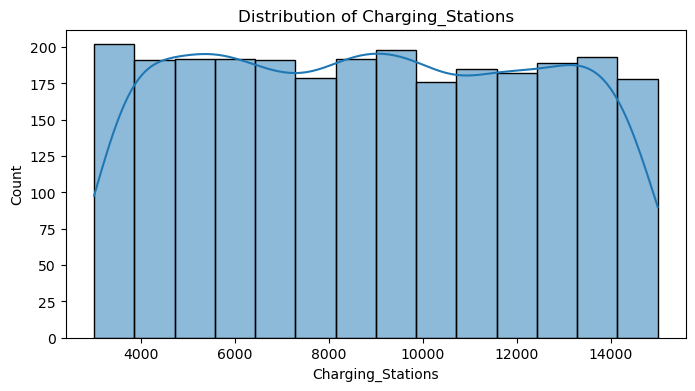

In [45]:
# Distribution Plots

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

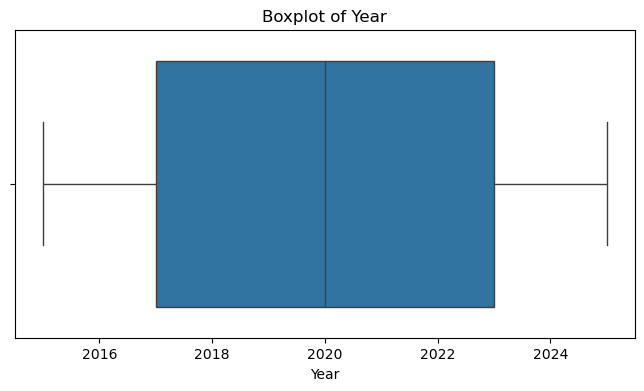

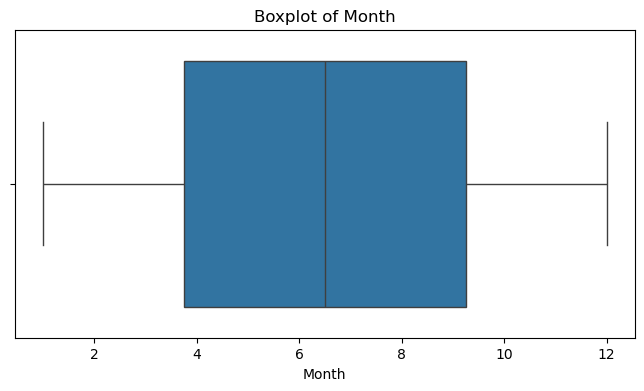

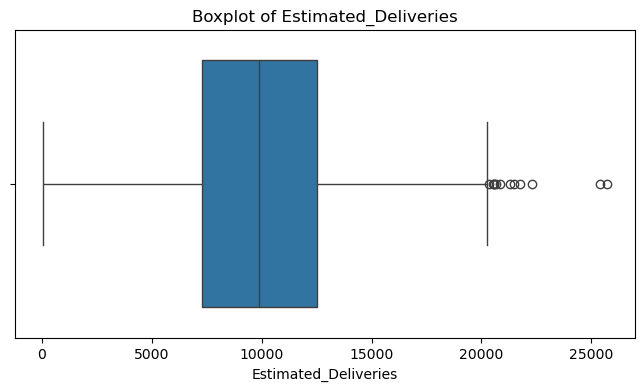

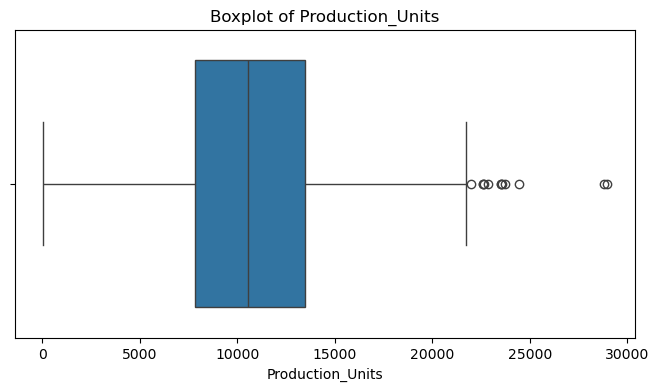

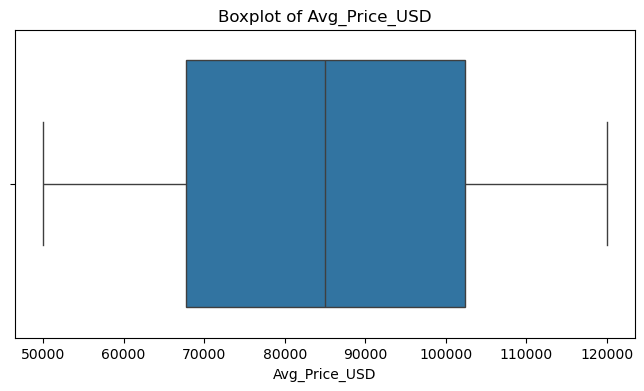

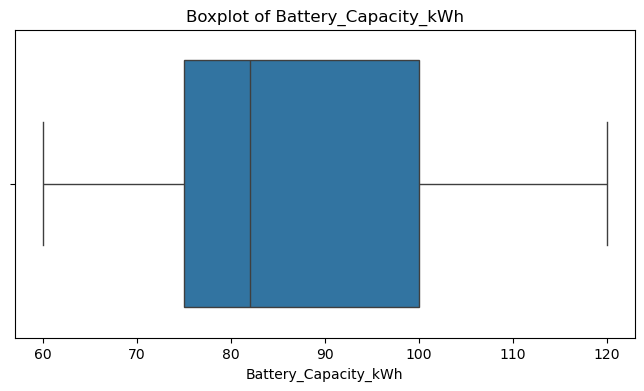

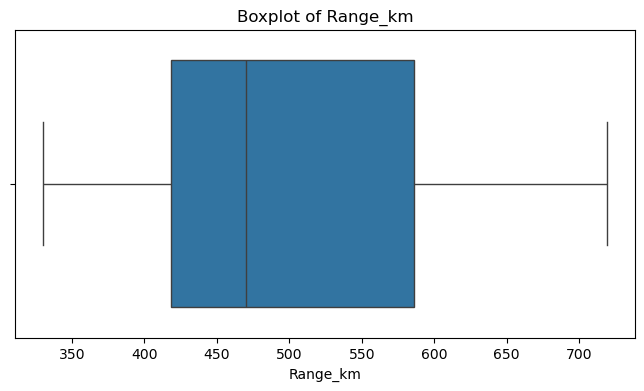

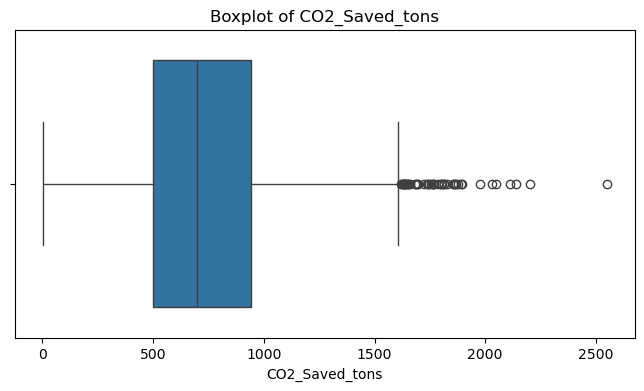

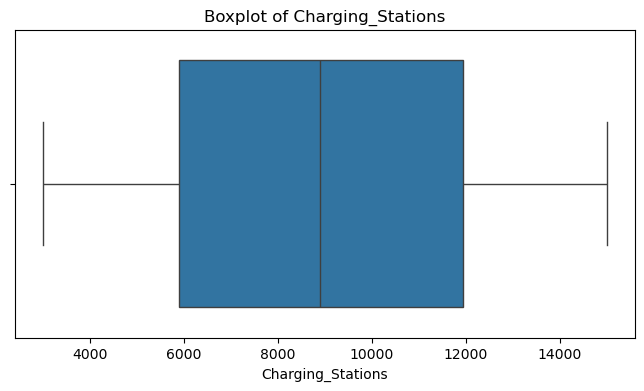

In [46]:
# Boxplots

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# FEATURE ENGINEERING


In [24]:
# Label Encoding for categorical columns

label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

In [ ]:
# TARGET VARIABLE SELECTION

print("\nColumns:")
print(df.columns)

TARGET_COLUMN = 'Estimated_Deliveries'


Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'year',
       'month', 'quarter'],
      dtype='object')


# TRAIN TEST SPLIT


In [27]:
X = df.drop(columns=[TARGET_COLUMN, DATE_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# FEATURE SCALING


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LINEAR REGRESSION MODEL


In [29]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

# RANDOM FOREST MODEL


In [30]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

# XGBOOST MODEL


In [31]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

# MODEL EVALUATION FUNCTION


In [32]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Performance")
    print("=" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

# EVALUATE MODELS


In [33]:
evaluate_model('Linear Regression', y_test, lr_preds)
evaluate_model('Random Forest', y_test, rf_preds)
evaluate_model('XGBoost', y_test, xgb_preds)


Linear Regression Performance
MAE  : 310.00
MSE  : 147047.61
RMSE : 383.47
R2   : 0.9901

Random Forest Performance
MAE  : 323.60
MSE  : 166937.53
RMSE : 408.58
R2   : 0.9888

XGBoost Performance
MAE  : 229.59
MSE  : 93757.71
RMSE : 306.20
R2   : 0.9937


# HYPERPARAMETER TUNING


In [34]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_grid.best_params_)

best_rf = rf_grid.best_estimator_

best_preds = best_rf.predict(X_test)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


# EVALUATE BEST MODEL


In [35]:
evaluate_model('Tuned Random Forest', y_test, best_preds)


Tuned Random Forest Performance
MAE  : 323.69
MSE  : 166944.76
RMSE : 408.59
R2   : 0.9888


# FEATURE IMPORTANCE



Feature Importance
                 Feature  Importance
4       Production_Units    0.990751
8         CO2_Saved_tons    0.002348
7               Range_km    0.001375
5          Avg_Price_USD    0.001300
10     Charging_Stations    0.001154
0                   Year    0.000468
3                  Model    0.000448
11                  year    0.000444
2                 Region    0.000394
1                  Month    0.000366
9            Source_Type    0.000322
12                 month    0.000320
6   Battery_Capacity_kWh    0.000161
13               quarter    0.000149


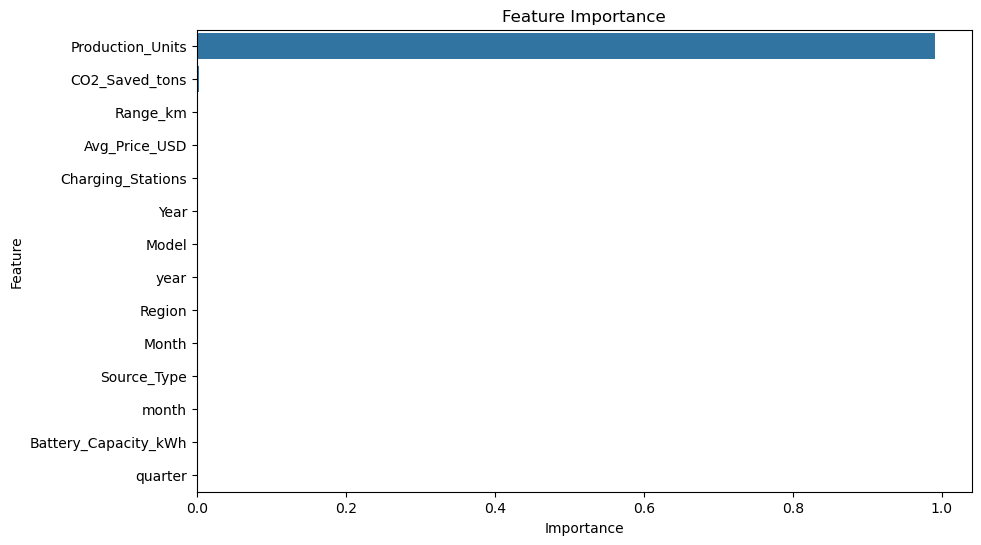

In [36]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

# SAVE MODEL


In [38]:
joblib.dump(best_rf, 'best_model.pkl')

print("\nModel saved successfully")


Model saved successfully


# TIME SERIES FORECASTING



Time Series Data
            Estimated_Deliveries
Date                            
2015-01-31              183180.0
2015-02-28              165053.0
2015-03-31              184567.0
2015-04-30              225623.0
2015-05-31              184264.0


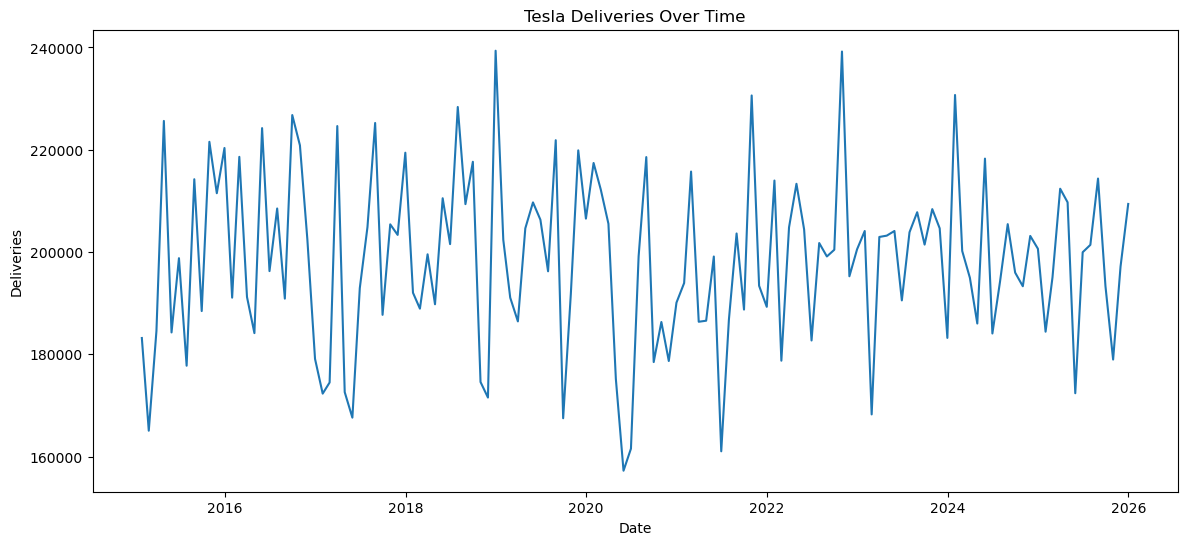

In [39]:
# Sort by date

df = df.sort_values(by=DATE_COLUMN)

# Time series target

ts_data = df[[DATE_COLUMN, TARGET_COLUMN]].copy()
ts_data.set_index(DATE_COLUMN, inplace=True)

# Monthly aggregation

ts_monthly = ts_data.resample('M').sum()

print("\nTime Series Data")
print(ts_monthly.head())

# Plot time series

plt.figure(figsize=(14, 6))
plt.plot(ts_monthly)
plt.title('Tesla Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.show()

# ARIMA MODEL


In [40]:
model = ARIMA(ts_monthly, order=(5, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

# Forecast next 12 months

forecast = model_fit.forecast(steps=12)

print("\nForecast Values")
print(forecast)

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(5, 1, 0)   Log Likelihood               -1489.328
Date:                  Sat, 16 May 2026   AIC                           2990.656
Time:                          13:53:19   BIC                           3007.907
Sample:                      01-31-2015   HQIC                          2997.666
                           - 12-31-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5502      0.047    -11.712      0.000      -0.642      -0.458
ar.L2         -0.3591      0.050     -7.137      0.000      -0.458      -0.260
ar.L3         -0.2469      0.051    

# FORECAST VISUALIZATION


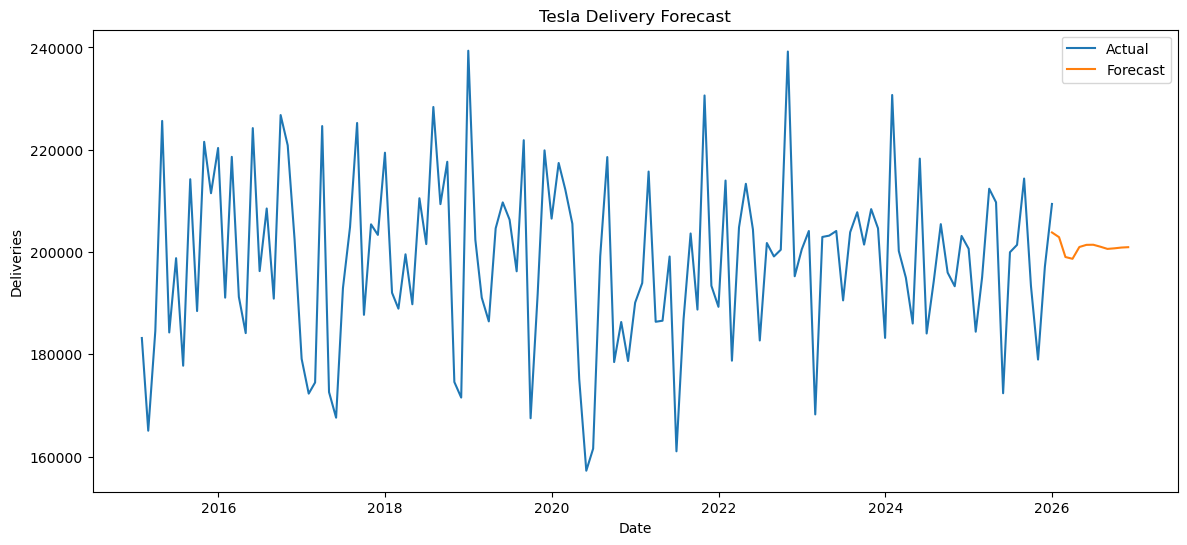

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(ts_monthly, label='Actual')

forecast_index = pd.date_range(
    start=ts_monthly.index[-1],
    periods=12,
    freq='M'
)

plt.plot(
    forecast_index,
    forecast,
    label='Forecast'
)

plt.title('Tesla Delivery Forecast')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.show()

# EXPORT FORECAST


In [42]:
forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecasted_Deliveries': forecast.values
})

forecast_df.to_csv(
    'tesla_forecast.csv',
    index=False
)

print("\nForecast exported successfully")


Forecast exported successfully


# Important ML Concepts Used

**Data Preprocessing :**
Handling Missing Values,
Duplicate Removal,
Encoding,
Feature Scaling

**EDA :**
Correlation Analysis,
Histograms,
Boxplots,
Trend Visualization

**Feature Engineering :**
Date-based Features,
Encoded Features

**Regression Models :**
Linear Regression,
Random Forest Regressor,
XGBoost Regressor

**Hyperparameter Tuning :**
GridSearchCV

**Time Series Forecasting :**
ARIMA Model,
Monthly Forecasting
